In [29]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transform
import torchvision
import torch
import numpy as np
import cv2
import random
import time
import os
import subprocess
import requests
import glob

In [2]:
np.random.seed(20)

In [25]:
model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT
)
_ = model.eval()

 # These are the classes that are available in the COCO-Dataset
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

COLORS = np.random.uniform(0, 255, size=(len(COCO_INSTANCE_CATEGORY_NAMES), 3))

In [4]:
def random_color_masks(image, colors):
    """
    Assigns a random color to each predicted object mask.

    Parameters:
        image (numpy.ndarray): Binary mask where detected object pixels are 1.
        colors (list): List of available colors for masks.

    Returns:
        numpy.ndarray: Colored mask of the same shape as the input.
    """
    # Create empty color channels
    r, g, b = np.zeros_like(image, dtype=np.uint8), np.zeros_like(image, dtype=np.uint8), np.zeros_like(image, dtype=np.uint8)

    # Assign a random color to the mask
    r[image == 1], g[image == 1], b[image == 1] = colors[random.randint(0, len(colors) - 1)]

    # Stack the channels to create a colored mask
    return np.stack([r, g, b], axis=2)


# Get predictions (masks, bounding boxes, and class labels) from the model
def get_prediction(img_path, threshold):
    """
    Performs object instance segmentation on an image.

    Parameters:
        img_path (str): Path to the input image.
        threshold (float): Confidence threshold for filtering predictions.

    Returns:
        tuple: (masks, bounding boxes, class labels)
    """
    # Load image using PIL
    img = Image.open(img_path)

    # Convert image to a PyTorch tensor
    img_tensor = T.ToTensor()(img)

    # Perform inference with the model in no-grad mode to save memory
    with torch.no_grad():
        pred = model([img_tensor])

    # Extract predictions and convert to NumPy arrays
    pred_data = pred[0]
    scores = pred_data['scores'].detach().cpu().numpy()
    labels = pred_data['labels'].detach().cpu().numpy()
    boxes = pred_data['boxes'].detach().cpu().numpy()
    masks = (pred_data['masks'] > 0.5).squeeze().detach().cpu().numpy()

    # Get index of last prediction above the threshold
    valid_indices = scores > threshold
    if not np.any(valid_indices):
        return [], [], []

    # Select predictions that meet the confidence threshold
    pred_boxes = [[(b[0], b[1]), (b[2], b[3])] for b in boxes[valid_indices]]
    pred_class = [COCO_INSTANCE_CATEGORY_NAMES[i] for i in labels[valid_indices]]
    masks = masks[valid_indices]

    return masks, pred_boxes, pred_class


# Perform instance segmentation and visualize the result
def instance_segmentation_api(img_path, threshold=0.5):
    """
    Performs instance segmentation on an image and displays the result.

    Parameters:
        img_path (str): Path to the input image.
        threshold (float, optional): Minimum confidence score for valid predictions. Defaults to 0.5.
    """
    # Get segmentation predictions
    masks, boxes, pred_cls = get_prediction(img_path, threshold)

    # Load the image using OpenCV and convert from BGR to RGB
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Calculate rectangle and text thickness based on image size
    rect_th = max(round(sum(img.shape) / 2 * 0.003), 2)
    text_th = max(rect_th - 1, 1)

    # Iterate over detected objects
    for i in range(len(masks)):
        # Get bounding box coordinates
        p1, p2 = (int(boxes[i][0][0]), int(boxes[i][0][1])), (int(boxes[i][1][0]), int(boxes[i][1][1]))

        # Generate a random color mask for the object
        rgb_mask = random_color_masks(masks[i], COLORS)

        # Blend mask with original image using weighted sum
        img = cv2.addWeighted(img, 1, rgb_mask, 0.5, 0)

        # Select bounding box color based on object class
        color = COLORS[COCO_INSTANCE_CATEGORY_NAMES.index(pred_cls[i])]

        # Draw bounding box around the detected object
        cv2.rectangle(img, p1, p2, color=color, thickness=rect_th)

        # Get text size for label display
        w, h = cv2.getTextSize(pred_cls[i], 0, fontScale=rect_th / 3, thickness=text_th)[0]
        outside = p1[1] - h >= 3  # Determine whether label should be inside or outside box
        p2 = (p1[0] + w, p1[1] - h - 3) if outside else (p1[0] + w, p1[1] + h + 3)

        # Draw filled rectangle as background for the class label
        cv2.rectangle(img, p1, p2, color=color, thickness=-1, lineType=cv2.LINE_AA)

        # Overlay the object class label on the image
        cv2.putText(
            img,
            pred_cls[i],
            (p1[0], p1[1] - 5 if outside else p1[1] + h + 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            rect_th / 3,
            (255, 255, 255),
            thickness=text_th + 1
        )

    # Display the final image with masks and bounding boxes
    plt.figure(figsize=(20, 17))
    plt.imshow(img)
    plt.axis("off")  # Hide axis labels
    plt.show()

Denoting the patth to where the images are located

In [26]:
directory = '/content/drive/MyDrive/data/Images'
os.makedirs(directory, exist_ok=True)

In [35]:
instance_segmentation_api(os.path.join(directory, '3.jpg'), 0.8)

Output hidden; open in https://colab.research.google.com to view.

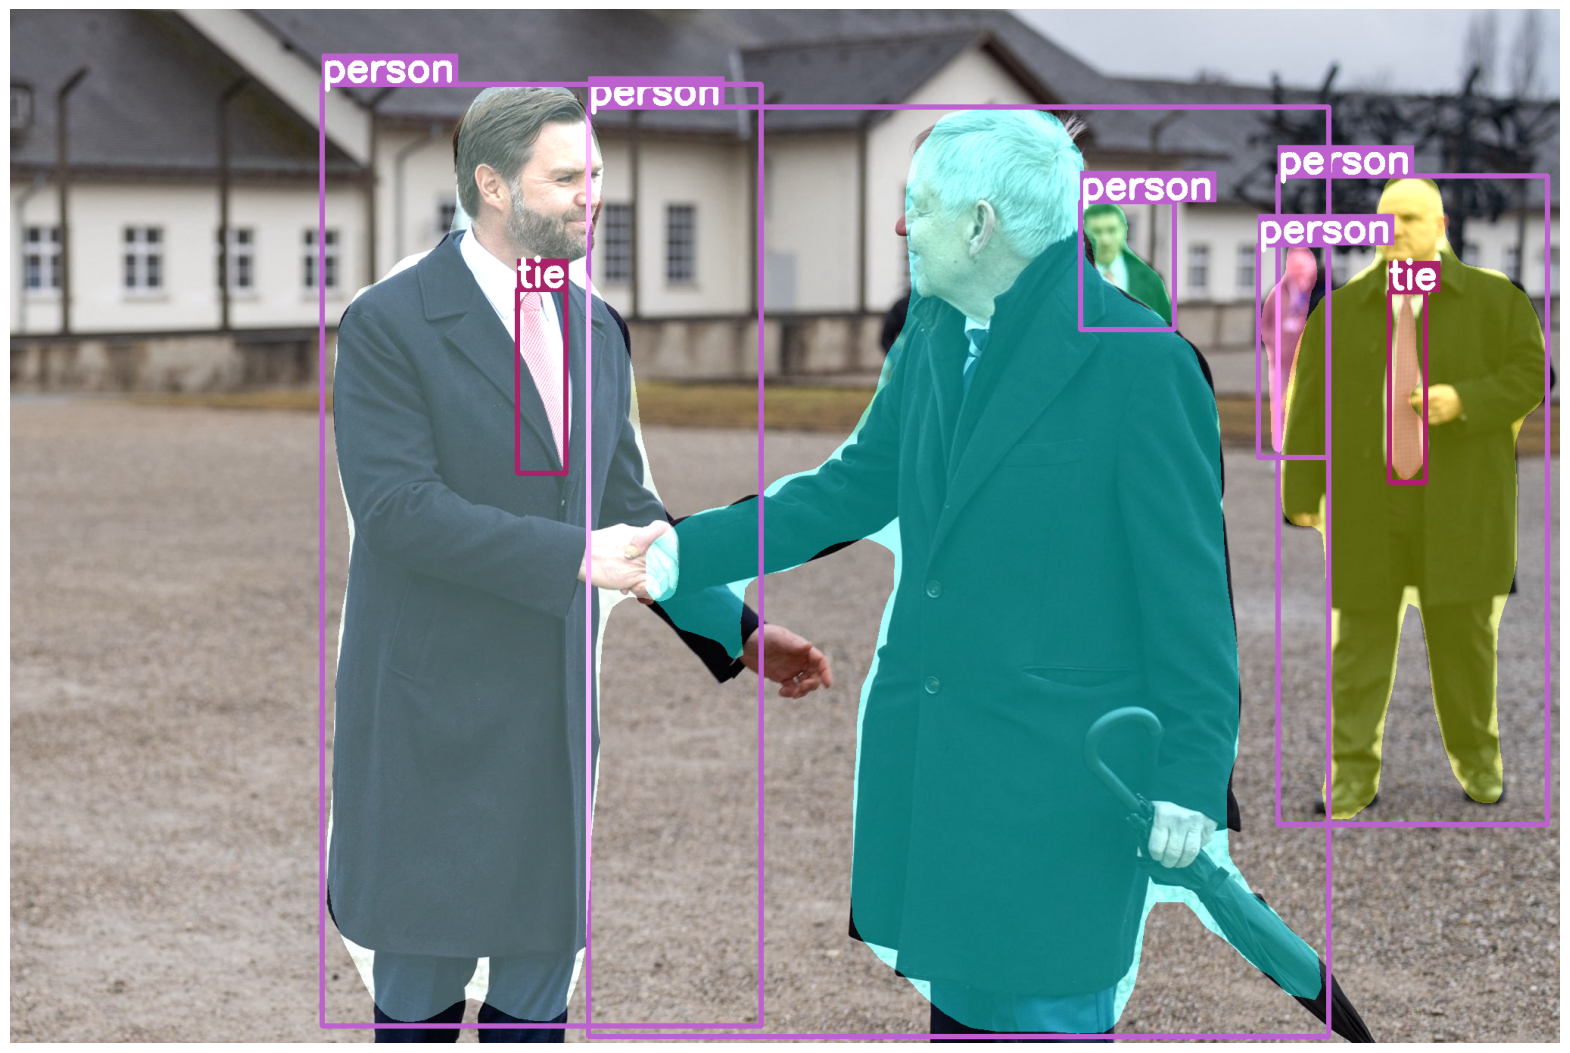

In [38]:
instance_segmentation_api(os.path.join(directory, '4.jpg'), 0.95)

In [39]:
instance_segmentation_api(os.path.join(directory, '5.jpg'), 0.8)

Output hidden; open in https://colab.research.google.com to view.

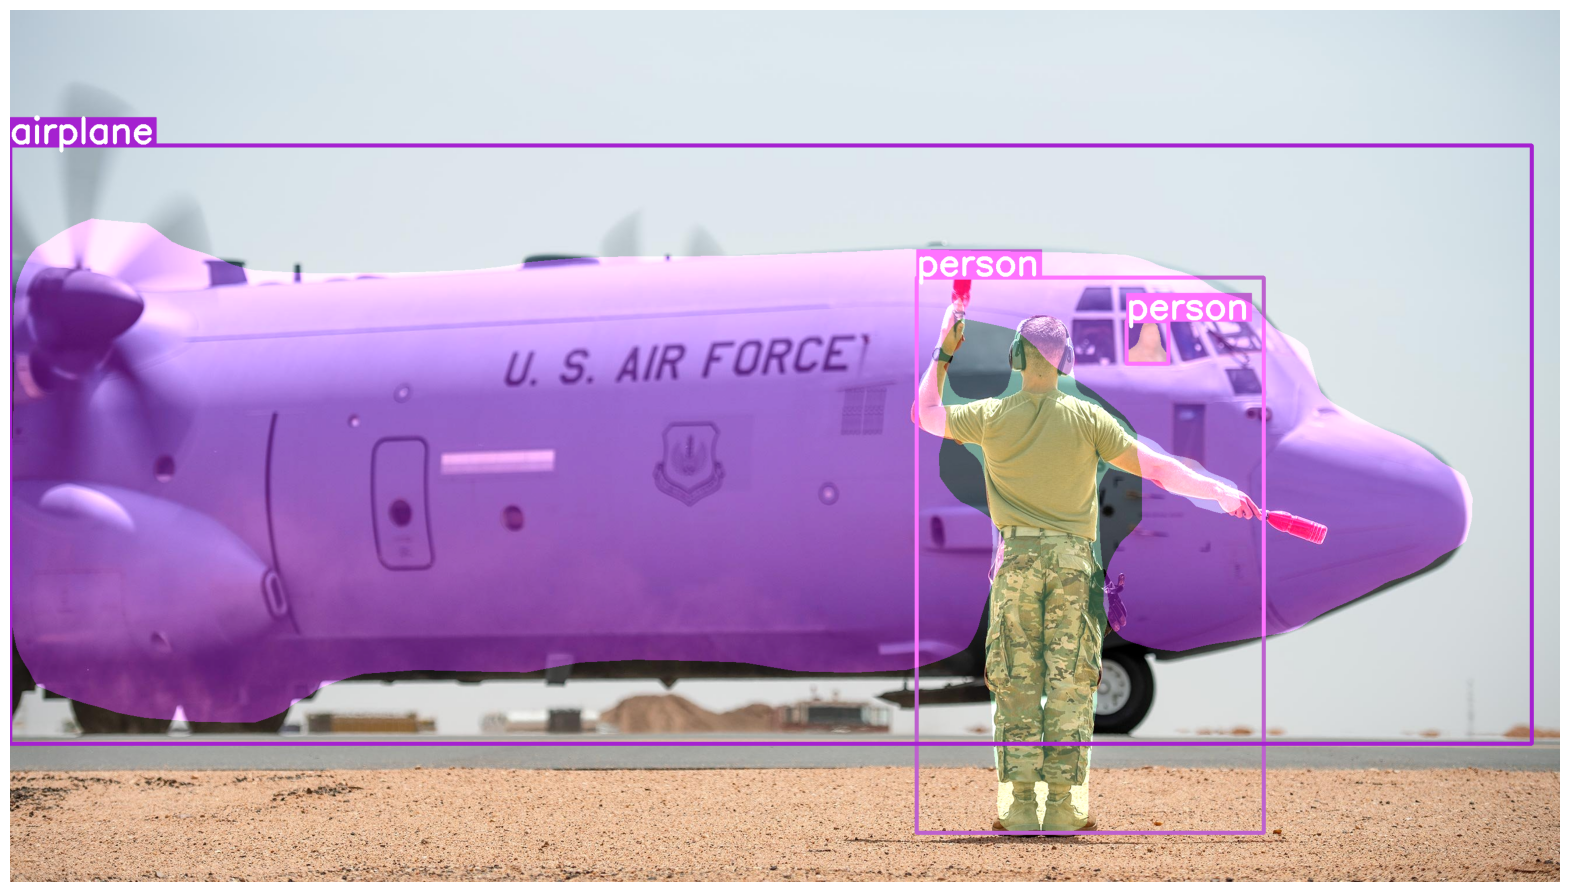

In [41]:
instance_segmentation_api(os.path.join(directory, '6.jpg'), 0.9)